# 🏃 **AICE ASSOCIATE 제6회 실전모의고사**  
## **생체 신호 기반 행동 예측**
---
* **도메인**: 헬스케어
* **목 표**: 웨어러블 센서 데이터를 활용하여 사용자의 실시간 **행동(activity)을 예측**하는 인공지능 모델 개발
* 스마트 헬스케어 기업 ‘에듀핏(Edu-Fit)’은 웨어러블 기기를 통해 수집되는 가속도, 자이로스코프 등 다양한 센서 데이터를 단순히 기록하는 데 그쳐, 사용자의 활동 상태에 따른 실시간 맞춤형 피드백을 제공하지 못하는 한계에 직면해 있다.
* 이러한 문제를 해결하기 위해, 에듀핏의 데이터 분석팀은 다차원 생체 신호 데이터를 분석하여 사용자의 **현재 활동을 정확하게 분류**하는 인공지능 모델을 도입하려 한다.
---

### **[데이터셋 소개]**
human_activity_selected.csv
### **[데이터 컬럼 설명]**
- tBodyAcc-mean()-X/Y/Z: 몸체 가속도의 평균값(X, Y, Z축)  
- tBodyAcc-std()-X/Y/Z: 몸체 가속도의 표준편차(X, Y, Z축)  
- tGravityAcc-mean()-X/Y/Z: 중력 가속도의 평균값(X, Y, Z축)  
- tBodyAccJerk-mean()-X/Y/Z: 몸체 가속도 변화율(Jerk)의 평균값(X, Y, Z축)  
- tBodyGyro-mean()-X/Y/Z: 자이로스코프(각속도)의 평균값(X, Y, Z축)  
- tBodyGyroJerk-mean()-X/Y/Z: 자이로 변화율(Jerk)의 평균값(X, Y, Z축)  
- tBodyAccMag-mean(): 몸체 가속도 벡터 크기의 평균  
- tGravityAccMag-mean(): 중력 가속도 벡터 크기의 평균  
- fBodyAcc-mean()-X/Y/Z: 주파수 영역 몸체 가속도의 평균값(X, Y, Z축)  
- angle(X,gravityMean), angle(Y,gravityMean): 중력 평균 벡터와의 각도(X축, Y축 기준)  
- **activity : 타겟 변수, 사용자의 실제 활동 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING)**
---

#### **1. 데이터를 로드하고 타깃 변수(activity)를 분석하여 분석 유형을 판별하세요. 아래 가이드에 따라 데이터를 불러온 후, 종속 변수(Target)의 구성 값을 확인하여 이번 프로젝트의 분석 목적을 정의하세요.**
---
* **(1-1) `pandas` 라이브러리를 임포트하여 데이터를 불러오고, 타깃 변수의 구성을 확인하는 코드를 작성하세요.**
    * **`human_activity_selected.csv`** 파일을 읽어서 **`df`** 변수에 저장하세요.
    * 데이터프레임의 상위 행을 확인하고, 특히 **`activity`** 컬럼의 **유일한 값(unique)** 또는 **빈도수**를 출력하여 데이터의 성격을 파악하세요.
* **(1-2) 확인한 `activity` 변수의 성격에 따라 해당 프로젝트는 어떤 분석 유형에 해당하나요? 가장 적절한 번호를 선택하세요.**
    * 1: 회귀(Regression) - 연속적인 수치 값 예측
    * 2: 분류(Classification) - 정해진 범주(Category) 판별
---

In [23]:
import pandas as pd
df = pd.read_csv('human_activity_selected.csv')

print(df.head())
print(f"\n {df['activity'].unique()}")

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0          -0.111188           0.031890           0.027904         -0.849474   
1          -0.063556          -0.001350          -0.105771         -0.858873   
2           0.069844           0.017360           0.066228          0.324112   
3          -0.102812           0.162292           0.082373          0.243959   
4          -0.066274          -0.014647          -0.084602          0.217751   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tGravityAcc-mean()-X  \
0         -0.058088         -0.052517             -0.057138   
1         -0.122084          0.020886             -0.195967   
2         -0.016821          0.116477             -0.024575   
3          0.089663         -0.061032             -0.031617   
4          0.108673          0.100499             -0.044177   

   tGravityAcc-mean()-Y  tGravityAcc-mean()-Z  tBodyAccJerk-mean()-X  ...  \
0             -0.592408             -0.261255               0.0

In [ ]:
분류

#### **2. 동적(Dynamic) 활동 데이터를 필터링하고 특정 생체 신호의 평균값을 산출하세요. 아래 가이드에 따라 사용자가 움직이고 있는 상태의 데이터만을 추출하여, 중력 가속도 신호의 특성을 수치화하고 분석하세요.**
---
* **대상 데이터**: **`df`**
* **(2-1) 동적 활동 데이터를 추출하고 특정 피처의 평균값을 계산하는 코드를 작성하세요.**
    * **`activity`** 컬럼의 값이 **'WALKING'**, **'WALKING_UPSTAIRS'**, **'WALKING_DOWNSTAIRS'** 에 해당하는 행만 필터링하여 **`dynamic_df`** 변수에 저장하세요.
    * **`dynamic_df`** 에서 **`tGravityAccMag-mean()`** 피처의 평균값을 출력하세요.(소수점 넷째 자리까지 반올림)
* **(2-2) 계산된 `tGravityAccMag-mean()`의 평균값은 얼마인가요?**
---

In [24]:
# (2-1) 여기에 답안코드를 작성하고 실행하세요.
# 동적 활동 리스트 정의
dynamic_activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

dynamic_df = df[df['activity'].isin(dynamic_activities)]

print(round(dynamic_df['tGravityAccMag-mean()'].mean(), 4))


-0.0011


In [ ]:
# (2-2) 여기에 답안을 입력하세요(실행 불필요).

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **3. 'STANDING' 활동 데이터의 분포를 시각화하고 이상치(Outlier) 존재 여부를 판별하세요. 아래 가이드에 따라 데이터를 필터링하고, 데이터를 분석하세요.**
---
* **대상 데이터**: **`df`**
* **(3-1) 'STANDING' 활동 데이터를 필터링하고 박스플롯을 시각화하는 코드를 작성하세요.**
    * **`activity`** 컬럼의 값이 **'STANDING'** 인 데이터만 추출하여 **`standing_df`** 변수에 저장하세요.
    * **`seaborn`** 라이브러리의 **`boxplot()`** 을 사용하여 **`tBodyAccMag-mean()`** 피처의 분포를 시각화하세요.
* **(3-2) 시각화된 그래프를 확인했을 때, 이상치(Outlier)가 존재하나요?**
    * 판단 결과(존재/미존재)를 입력하세요.
---

<Axes: ylabel='tBodyAccMag-mean()'>

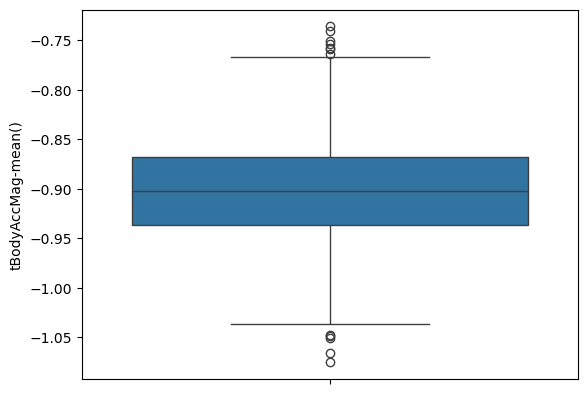

In [26]:
standing_df = df[df['activity']=='STANDING']
sns.boxplot(data=standing_df, y='tBodyAccMag-mean()')

In [ ]:
# (3-2) 여기에 답안을 입력하세요(실행 불필요).

#### **4. 활동 유형별 신체 가속도 변화량의 분포를 비교하고 정적 활동의 특성을 파악하세요. 아래 가이드에 따라 히스토그램을 생성하여 활동별 데이터의 분포 차이를 시각적으로 분석하세요.**
---
* **대상 데이터**: **`df`**
* **(4-1) 활동(activity)별 `tBodyAcc-std()-X` 피처의 분포를 비교하는 시각화 코드를 작성하세요.**
    * **`seaborn`** 라이브러리의 **`histplot()`** 을 사용하세요.
    * **`tBodyAcc-std()-X`** 피처를 설정하고, **`activity`** 별로 색상을 다르게 표현하세요.
    * 분포의 흐름을 부드럽게 확인할 수 있도록 **`kde=True`** 옵션을 추가하세요.
* **(4-2) 시각화 결과, X축 방향의 움직임 변화량(표준편차)이 가장 적게 나타나는(그래프가 가장 왼쪽에 치우친) 활동의 이름은 무엇인가요?**
---

<Axes: xlabel='tBodyAcc-std()-X', ylabel='Count'>

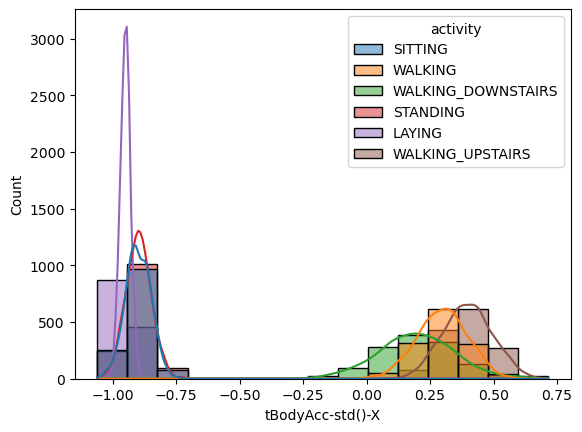

In [27]:
sns.histplot(df, x='tBodyAcc-std()-X', hue='activity', kde=True)

In [ ]:
# (4-2) 여기에 답안을 입력하세요(실행 불필요).

#### **5. 여러 개의 생체 신호 피처에 존재하는 누락된 값을 중앙값(Median)으로 일괄 처리하고, 정제 상태를 확인하세요. 아래 가이드에 따라 결측치 처리를 하세요.**
---
* **대상 데이터**: **`df`**
* `for` 반복문을 사용하여 `nan_cols` 리스트 내 컬럼들에 대해 일괄 결측치 처리하세요.
* 각 컬럼의 결측치를 해당 컬럼의 **중앙값(median)** 으로 보간하세요.
* 처리 후 전체 데이터프레임의 결측치가 0건임을 확인하세요.
---

In [28]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.

#대상 컬럼을 정의하세요.
nan_cols = ['tBodyAcc-std()-Y', 'tGravityAcc-mean()-Z', 'tBodyGyro-mean()-X', 'fBodyAcc-mean()-Y', 'angle(X,gravityMean)']

# 빈칸을 채워 결측치 보간을 완료하고 결과를 확인하세요.
for col in nan_cols:
    df[col] = df[col].fillna(df[col].median())

# 최종 결측치 합계 확인
print(df.isnull().sum().sum())

0


In [ ]:
# (5-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (5-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (5-3) 여기에 답안을 입력하세요(실행 불필요).

#### **6. IQR(Interquartile Range) Rule을 활용하여 이상치를 식별하고 제거하세요. 아래 가이드에 따라 잘못된 로직을 수정하여 정상 범위를 벗어난 데이터를 정제하세요.**
---
* **대상 데이터**: **`df`** (대상 컬럼: **`tBodyAccMag-mean()`**)
* **(6-1) 이상치를 처리하세요.**
    - 데이터의 하위 25%(`Q1`)와 상위 75%(`Q3`) 지점을 정의하여 중앙 데이터의 분포 범위를 파악하세요.
    - 두 사분위수 간의 거리(`IQR`)를 산출하고, 이를 바탕으로 정상 데이터가 존재할 수 있는 상·하단 경계(임계값)를 설정하세요.
    - 설정된 임계값 범위 내의 정상 데이터만을 추출하세요.
* **(6-2) 데이터 정제 후 최종적으로 남은 행(Row)의 개수는?**
---

In [29]:
# (6-1) 여기에 코드의 오류를 정정하고 실행하세요.
Q1 = df['tBodyAccMag-mean()'].quantile(0.25)
Q3 = df['tBodyAccMag-mean()'].quantile(0.75)
IQR = Q3 - Q1

lower_boundary = Q1 - 1.5 * IQR
upper_boundary = Q3 + 1.5 * IQR

df = df[(df['tBodyAccMag-mean()'] >= lower_boundary) & (df['tBodyAccMag-mean()'] <= upper_boundary)]

print(len(df))

7990


In [ ]:
# (6-2) 여기에 답안을 입력하세요(실행 불필요).

#### **7. 범주형 타겟 데이터를 수치형으로 변환하고 분류 클래스의 규모를 확인하세요. 아래 가이드에 따라 레이블 인코딩(Label Encoding)을 수행하여 모델 학습이 가능한 형태로 데이터를 정제하세요.**
---
* **대상 데이터**: **`df['activity']`**
* **(7-1) 아래 단계에 따라 타겟 변수를 인코딩하는 코드를 작성하고 실행하세요.**
    - **`LabelEncoder`** 를 사용하여 원래 문자열인 **`activity`** 컬럼의 데이터를 정수형으로 변환하여 덮어쓰세요.
    - 변환된 **`activity`** 컬럼에 실제로 어떤 값들이 담겨 있는지 유일한 값(unique)들을 출력하여 확인하세요.
    - 인코딩된 정수값과 매칭되는 원래 클래스(문자열)의 명칭들을 함께 확인하세요.
* **(7-2) 인코딩 결과, 이 데이터셋이 분류해야 할 최종 행동(activity) 클래스는 총 몇 가지인가요?**
---

In [30]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['activity'] = encoder.fit_transform(df['activity'])

print(df['activity'].unique())
print(encoder.classes_)



[1 3 4 2 0 5]
['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [ ]:
# (7-2) 여기에 답안을 입력하세요(실행 불필요).

#### **8. 모델 학습 및 검증을 위한 데이터셋 분리 및 데이터 불균형을 방지하세요. 아래 가이드에 따라 학습용과 테스트용 데이터를 분할하세요.**
---
* **대상 데이터**: **`df`**
* **아래 단계에 따라 데이터를 분리하는 코드를 작성하고 실행하세요.**
    * 전체 데이터에서 **`activity`** 컬럼을 제외한 피처들을 **`X`** 에, **`activity`** 컬럼만을 **`y`** 에 할당하세요.
    * **`train_test_split`** 라이브러리를 활용하여 학습 데이터와 테스트 데이터를 **80:20** 비율로 분할하세요.
        * X_train, X_test, y_train, y_test 변수명 사용
        * 타겟 변수의 클래스 분포가 편중되지 않도록 **`stratify`** 옵션 적용
        * 난수 발생 시드 **42**로 설정
---

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop('activity', axis=1)
y = df['activity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### **9. 피처 스케일링(Scaling)을 수행하여 데이터의 변동성을 조절하고 모델의 수렴 속도를 향상시키세요. 아래 가이드에 따라 독립 변수들의 범위를 스케일링하세요.**
---
* **대상 데이터**: **`X_train`**, **`X_test`**
* **아래 가이드에 따라 피처 스케일링을 수행하는 코드를 작성하고 실행하세요.**
    * **`sklearn.preprocessing`** 라이브러리에서 이상치(Outlier)에 강건한 **`RobustScaler`** 를 사용하세요.
    * 학습 데이터(**`X_train`**)를 기준으로 스케일러를 학습(fit)시키고 변환(transform)하여 **`X_train_scaled`** 에 저장하세요.
    * 동일한 스케일러를 사용하여 검증 데이터(**`X_test`**)를 변환하고 **`X_test_scaled`** 에 저장하세요.
---

In [32]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




#### **10. 다중 알고리즘 기반 분류 모델 구축 및 하이퍼파라미터 설정을 수행하세요. 아래 가이드에 따라 두 가지 분류 알고리즘으로 사용자의 행동을 학습시키세요.**
---
* **대상 데이터**: **`X_train_scaled`**, **`y_train`**
* **아래 가이드에 따라 2가지 모델을 생성하고 학습시키는 코드를 작성하세요.**
    * **`GradientBoostingClassifier`** 모델을 생성하고 변수 **gb** 에 할당하고 학습시키세요.
        * 결정 트리(n_estimators) 수: 100
        * 학습률: 0.05
        * 최대 깊이: 3
        * 난수 시드: 42
    * **`LogisticRegression`** 모델을 생성하고 변수 **lr** 에 할당하고 학습시키세요.
        * 규제 강도(C): 0.1
        * 최대 반복 횟수(max_iter): 50
        * 난수 시드: 42
---

In [34]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=100, max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)

lr = LogisticRegression(C=0.1, max_iter=50, random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,50
,multi_class,'deprecated'


#### **11. 학습된 모델들의 예측 성능을 평가하고 최적의 알고리즘을 선정하세요. 아래 가이드에 따라 F1-score 기준으로 모델의 성능을 비교 분석하세요.**
---
* **(11-1) 아래 가이드에 따라 잘못된 코드를 정정하여 실행하세요.**
    * 학습된 **`gb`** 모델과 **`lr`** 모델을 사용하여 테스트 데이터에 대한 예측값을 생성하세요.
    * **`sklearn.metrics`** 의 **`f1_score`** 를 사용하여 각 모델의 성능을 측정하세요.
    * 다중 분류 상황을 고려하여 클래스별 불균형을 반영하는 **`average='weighted'`** 옵션을 적용하세요.
* **(11-2) 두 모델의 F1-score를 비교했을 때, 최종적으로 선정된 최적 모델은 무엇인지 해당 번호를 기입하세요.**
    - 1: LogisticRegression
    - 2: GradientBoostingClassifier
---

In [35]:
# (11-1) 여기에 코드의 오류를 정정하고 실행하세요.

from sklearn.metrics import f1_score

pred_gb = gb.predict(X_test_scaled)
f1_gb = f1_score(y_test, pred_gb, average='weighted')

pred_lr = lr.predict(X_test_scaled)
f1_lr = f1_score(y_test, pred_lr, average='weighted')

print(f"LR F1-score: {f1_lr:.4f}")
print(f"GB F1-score: {f1_gb:.4f}")

LR F1-score: 0.6902
GB F1-score: 0.1086


In [ ]:
# (11-2) 여기에 답안을 입력하세요(실행 불필요).

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(42)

#### **12. 생체신호행동 예측을 위한 딥러닝 모델 설계 및 콜백(Callback) 기능을 활용한 모델 최적화를 수행하세요. 아래 토폴로지 다이어그램과 가이드를 참고하여 모델링하고 학습을 수행하세요.**
---
* **모델 설계**
    - **`Sequential`** 모델을 사용하여 제공된 토폴로지에 따라 히든 레이어를 구성하세요.
    - 마지막 아웃풋 레이어의 노드 수와 activation 함수는 모델 유형에 맞게 구성하세요.
* **콜백(Callback) 설정**
    - 조기 종료를 사용하여 10번의 epoch 동안 모니터링 지표가 향상되지 않을 경우 훈련을 중지하도록 설정하고 **`es`** 변수에 저장하세요.
    - 모델 체크 포인트를 사용하여 최적 모델을 **'best_dl_model.keras'** 로 저장하도록 설정하고 **`mc`** 변수에 저장하세요.
* **모델 학습 설정**
    - `optimizer`는 adam 손실 함수는 mse로 지정하여 모델을 컴파일하세요.
    - 다음 조건에 따라 모델을 학습하고 학습 정보는 **`history`** 변수에 저장하세요.
        * **`batch_size`**: 32
        * **`epochs`**: 50
        * **`callbacks`**: 위에서 설정한 **`es`**, **`mc`** 변수를 리스트 형태로 입력하세요.
        * 모델의 성능을 실시간으로 검증하기 위해 미리 분리해둔 검증 데이터 할당하세요.
    - 안내된 내용 외 별도의 파라미터는 입력하지 마세요.
---

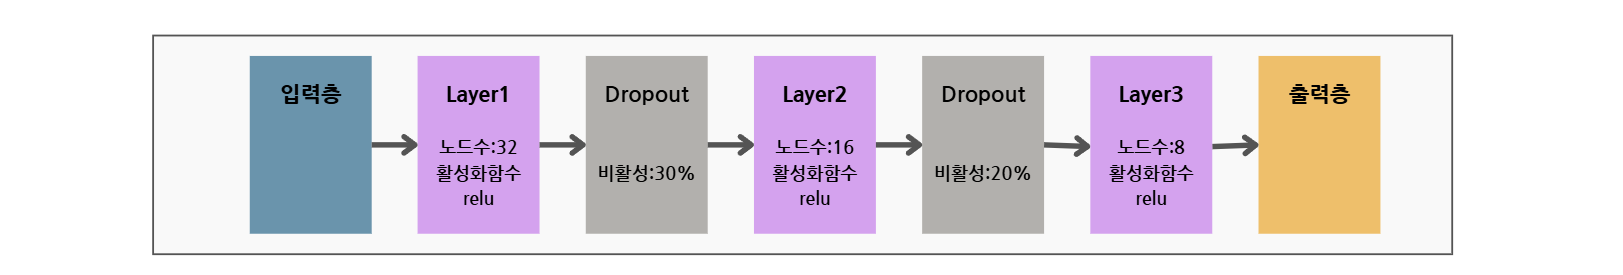

In [37]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요
dl_model = Sequential()
dl_model.add(Dense(units=32, activation='relu',input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dropout(0.3))
dl_model.add(Dense(units=16, activation='relu'))
dl_model.add(Dropout(0.2))
dl_model.add(Dense(units=8, activation='relu'))
dl_model.add(Dense(units=y_test.nunique(), activation='softmax'))

dl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10)
mc = ModelCheckpoint('best_activity_model.keras', monitor='val_loss', save_best_only=True)

history = dl_model.fit(X_train_scaled, y_train,
                       epochs=200, batch_size=32,
                       validation_data=(X_test_scaled, y_test),
                       callbacks=[es, mc])

C:\Users\kun99\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2459 - loss: 1.6869 - val_accuracy: 0.3423 - val_loss: 1.3632
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3841 - loss: 1.2509 - val_accuracy: 0.4506 - val_loss: 1.0456
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4498 - loss: 1.0789 - val_accuracy: 0.5282 - val_loss: 0.9513
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5116 - loss: 0.9976 - val_accuracy: 0.5964 - val_loss: 0.8606
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5452 - loss: 0.9242 - val_accuracy: 0.6345 - val_loss: 0.7833
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5824 - loss: 0.8711 - val_accuracy: 0.6902 - val_loss: 0.7241
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5984 - loss: 0.8409 - val_accuracy: 0.6884 - val_loss: 0.7005
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6316 - loss: 0.8058 - val_accu

In [ ]:
# (12-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (12-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (12-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (12-4) 여기에 답안을 입력하세요(실행 불필요).

#### **13. 학습 과정 시각화 결과를 바탕으로 모델의 과적합 여부와 조기 종료(Early Stopping)를 진단하세요. 아래의 코드를 실행하여 시각화 분석하세요.**
---
* **(13-1) 아래 제공된 시각화 코드를 수정 없이 실행하여 학습 정확도와 손실 그래프를 출력하세요.**
    * 그래프를 통해 학습 데이터(**`train`**)와 검증 데이터(**`validation`**) 간의 성능 추이 및 격차를 확인하세요.
* **(13-2) 모델 설정 시 지정한 전체 에포크(200회)와 실제 수행된 에포크 수를 비교했을 때, 조기 종료(Early Stopping)가 발생했나요?**
    * 1. **네**, 검증 손실이 개선되지 않아 설정된 횟수 이전에 학습이 종료됨
    * 2. **아니오**, 설정된 200회 에포크를 모두 수행함
---

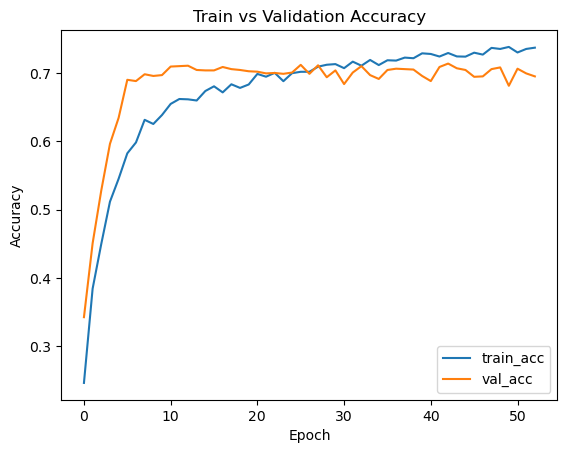

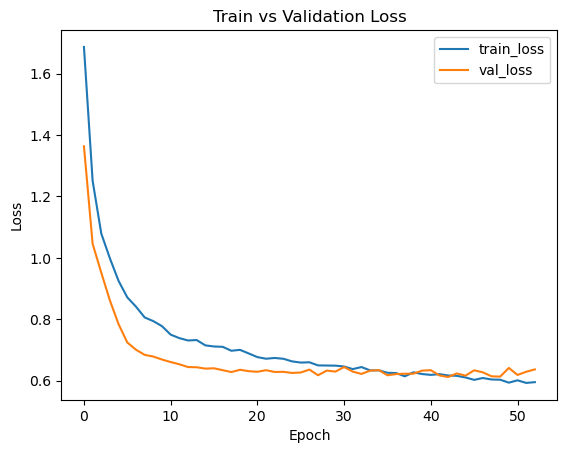

In [38]:
# (13-1) 제공된 시각화 코드를 실행하여 학습 결과를 확인하세요.
# ----- 1. 정확도 시각화 -----
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.show()

# ----- 2. 손실 시각화 -----
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
# (13-2) 여기에 답안을 입력하세요(실행 불필요).

#### **14. 학습된 최적 모델을 로드하여 보검이의 실시간 행동을 예측하세요. 보검이가 착용한 센서에서 수집된 실시간 생체 신호 데이터를 활용하여, 인공지능 모델이 판단한 보검이의 현재 활동명을 도출하세요.**
---
* **(14-1) 아래 가이드에 따라 최적 모델을 불러오고 예측을 수행하는 코드를 작성하세요.**
    * 저장된 **'best_activity_model.keras'** 파일을 불러와 **`best_model`** 변수에 저장하세요.
    * 제공된 보검이의 생체 신호(**`new_data`**)에 대한 예측 확률값을 생성하세요.
    * 확률값이 가장 높은 인덱스를 추출하고, 이전 단계에서 사용한 레이블 인코더(**`le`**)의 **`inverse_transform`** 을 사용하여 실제 활동명(문자열)으로 변환하세요.
    * 최종 예측된 활동명을 출력하여 확인하세요.
* **(14-2) 보검이의 실시간 생체 신호를 분석한 결과, 모델이 예측한 현재 보검이의 활동은 무엇인가요?**
---

In [39]:
# (14-1) 여기에 답안코드를 작성하고 실행하세요.
# 보검이의 실시간 생체 신호 데이터(스케일링 처리 완료)
new_data=np.array([[-0.30220005,  0.45768456,  1.80021891, -0.66791508,  0.29523195,
         0.71789722,  1.17549744,  0.40061864, -0.59636902, -0.06873771,
        -0.70462027, -1.62872918,  0.0735179 , -0.95773435, -0.66899568,
        -0.39573429, -0.88419615, -0.00998886, -0.20019575,  1.65011582,
         0.53200416, -0.01193946, -0.03656269, -0.00767125, -0.15099404]])

In [44]:
best_model = load_model('best_activity_model.keras')

new_pred = best_model.predict(new_data)

new_encod = encoder.inverse_transform([new_pred.argmax()])[0]
print(new_encod)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
LAYING
